In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "5d733eab198ad58f23ceee3f1550014385366ece"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/5d733eab198ad58f23ceee3f1550014385366ece/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Q-Learning

In the previous section, we discussed the Value Iteration algorithm which requires accessing the complete Markov decision process (MDP), e.g., the transition and reward functions. In this section, we will look at Q-Learning [@Watkins.Dayan.1992] which is an algorithm to learn the value function without necessarily knowing the MDP. This algorithm embodies the central idea behind reinforcement learning: it will enable the robot to obtain its own data.
<!-- , instead of relying upon the expert. -->

## The Q-Learning Algorithm

Recall that value iteration for the action-value function in that section corresponds to the update

$$Q_{k+1}(s, a) = r(s, a) + \gamma \sum_{s' \in \mathcal{S}} P(s' \mid s, a) \max_{a' \in \mathcal{A}} Q_k (s', a'); \ \textrm{for all } s \in \mathcal{S} \textrm{ and } a \in \mathcal{A}.$$

As we discussed, implementing this algorithm requires knowing the MDP, specifically the transition function $P(s' \mid s, a)$. The key idea behind Q-Learning is to replace the summation over all $s' \in \mathcal{S}$ in the above expression by a summation over the states visited by the robot. This allows us to subvert the need to know the transition function.

## An Optimization Problem Underlying Q-Learning

Let us imagine that the robot uses a policy $\pi_e(a \mid s)$ to take actions, and that it collects a dataset of $n$ trajectories of $T$ timesteps each $\{ (s_t^i, a_t^i)_{t=0,\ldots,T-1}\}_{i=1,\ldots, n}$. Recall that value iteration is really a set of constraints that ties together the action-value $Q^*(s, a)$ of different states and actions to each other. We can implement an approximate version of value iteration using the data that the robot has collected using $\pi_e$ as

$$\hat{Q} = \mathrm{argmin}_Q \underbrace{\frac{1}{nT} \sum_{i=1}^n \sum_{t=0}^{T-1} (Q(s_t^i, a_t^i) - r(s_t^i, a_t^i) - \gamma \max_{a'} Q(s_{t+1}^i, a'))^2}_{\stackrel{\textrm{def}}{=} \ell(Q)}.$$

Let us first observe the similarities and differences between this expression and value iteration above. If the robot's data-collection policy $\pi_e$ visited every state-action pair, and if it collected an infinite amount of data, then this optimization problem would pin down the same solution as value iteration. Note that an optimal deterministic policy would *not* qualify: it never takes the actions it considers suboptimal, so $\ell(Q)$ would contain no term for those state-action pairs and their values would be left unconstrained. The section on exploration below returns to this point. But while value iteration requires us to know $P(s' \mid s, a)$, the optimization objective does not have this term. We have not cheated: as the robot uses the policy $\pi_e$ to take an action $a_t^i$ at state $s_t^i$, the next state $s_{t+1}^i$ is a sample drawn from the transition function. So the optimization objective also has access to the transition function, but implicitly in terms of the data collected by the robot.

The variables of our optimization problem are $Q(s, a)$ for all $s \in \mathcal{S}$ and $a \in \mathcal{A}$. We can minimize the objective with updates of a gradient-descent flavor. For every pair $(s_t^i, a_t^i)$ in our dataset, we take a step on the corresponding squared-error term while treating the bootstrapped target $r(s_t^i, a_t^i) + \gamma \max_{a'} Q(s_{t+1}^i, a')$ as fixed, i.e., we do not differentiate through the $Q$ inside the target. Folding the remaining constant factors into the learning rate $\alpha$, the update becomes

$$Q(s_t^i, a_t^i) \leftarrow (1 - \alpha) Q(s_t^i,a_t^i) + \alpha \Big( r(s_t^i, a_t^i) + \gamma \max_{a'} Q(s_{t+1}^i, a') \Big),$$

where $\alpha$ is the learning rate. Because the target itself depends on $Q$ and we deliberately hold it fixed, this is called a semi-gradient step: Q-Learning is not gradient descent on $\ell(Q)$ in the strict sense, but the update is simple, cheap, and works well in practice. Typically in real problems, when the robot reaches the goal location, the trajectories end. The value of such a terminal state is zero because the robot does not take any further actions beyond this state. We should modify our update to handle such states as

$$Q(s_t^i, a_t^i) \leftarrow (1 - \alpha) Q(s_t^i,a_t^i) + \alpha \Big( r(s_t^i, a_t^i) + \gamma (1 - \mathbb{1}_{s_{t+1}^i \textrm{ is terminal}} )\max_{a'} Q(s_{t+1}^i, a') \Big),$$

where $\mathbb{1}_{s_{t+1}^i \textrm{ is terminal}}$ is an indicator variable that is one if $s_{t+1}^i$ is a terminal state and zero otherwise. The value of state-action tuples $(s, a)$ that are not a part of the dataset is initialized to zero. This algorithm is known as Q-Learning.

Given the solution of these updates $\hat{Q}$, which is an approximation of the optimal value function $Q^*$, we can obtain the optimal deterministic policy corresponding to this value function easily using

$$\hat{\pi}(s) = \mathrm{argmax}_{a} \hat{Q}(s, a).$$

There can be situations when there are multiple deterministic policies that correspond to the same optimal value function; such ties can be broken arbitrarily because they have the same value function.

## Exploration in Q-Learning

The policy used by the robot to collect data $\pi_e$ is critical to ensure that Q-Learning works well. After all, we have replaced the expectation over $s'$ using the transition function $P(s' \mid s, a)$ using the data collected by the robot. If the policy $\pi_e$ does not reach diverse parts of the state-action space, then it is easy to imagine our estimate $\hat{Q}$ will be a poor approximation of the optimal $Q^*$. It is also important to note that in such a situation, the estimate of $Q^*$ at *all states* $s \in \mathcal{S}$ will be bad, not just the ones visited by $\pi_e$. This is because the Q-Learning objective (or value iteration) is a constraint that ties together the value of all state-action pairs. It is therefore critical to pick the correct policy $\pi_e$ to collect data.

We can mitigate this concern by picking a completely random policy $\pi_e$ that samples actions uniformly randomly from $\mathcal{A}$. Such a policy would visit all states, but it will take a large number of trajectories before it does so.

We thus arrive at the second key idea in Q-Learning, namely exploration. Typical implementations of Q-Learning tie together the current estimate of $Q$ and the policy $\pi_e$ to set

$$\pi_e(a \mid s) = \begin{cases} 1 - \epsilon + \epsilon/|\mathcal{A}| & a = \mathrm{argmax}_{a'} \hat{Q}(s, a') \\ \epsilon/|\mathcal{A}| & \textrm{otherwise}, \end{cases}$$

where $\epsilon$ is called the "exploration parameter" and is chosen by the user. The policy $\pi_e$ is called an exploration policy. This particular $\pi_e$ is called an $\epsilon$-greedy exploration policy: probability $\epsilon$ is spread uniformly over all actions, and the remaining $1-\epsilon$ goes to the best action under the current estimate $\hat{Q}$, so that action is taken with total probability $1 - \epsilon + \epsilon/|\mathcal{A}|$ (ties in the argmax are broken arbitrarily). We can also use the so-called softmax exploration policy

$$\pi_e(a \mid s) = \frac{e^{\hat{Q}(s, a)/\tau}}{\sum_{a'} e^{\hat{Q}(s, a')/\tau}};$$

where the hyper-parameter $\tau$ is called temperature (we use $\tau$ to avoid clashing with the trajectory length $T$ introduced above). A large value of $\epsilon$ in $\epsilon$-greedy policy functions similarly to a large value of temperature $\tau$ for the softmax policy.

It is important to note that when we pick an exploration that depends upon the current estimate of the action-value function $\hat{Q}$, we need to resolve the optimization problem periodically. Typical implementations of Q-Learning make one mini-batch update using a few state-action pairs in the collected dataset (typically the ones collected from the previous timestep of the robot) after taking every action using $\pi_e$.

## The "Self-correcting" Property of Q-Learning

The dataset collected by the robot during Q-Learning grows with time. Both the exploration policy $\pi_e$ and the estimate $\hat{Q}$ evolve as the robot collects more data. This gives us a key insight into why Q-Learning works well. Consider a state $s$: if a particular action $a$ has a large value under the current estimate $\hat{Q}(s,a)$, then both the $\epsilon$-greedy and the softmax exploration policies have a larger probability of picking this action. If this action actually is *not* the ideal action, then the future states that arise from this action will have poor rewards. The next update of the Q-Learning objective will therefore reduce the value $\hat{Q}(s,a)$, which will reduce the probability of picking this action the next time the robot visits state $s$. Bad actions, e.g., ones whose value is overestimated in $\hat{Q}(s,a)$, are explored by the robot but their value is correct in the next update of the Q-Learning objective. Good actions, e.g., whose value $\hat{Q}(s, a)$ is large, are explored more often by the robot and thereby reinforced. This property can be used to show that Q-Learning can converge to the optimal policy even if it begins with a random policy $\pi_e$ [@Watkins.Dayan.1992].

This ability to not only collect new data but also collect the right kind of data is the central feature of reinforcement learning algorithms, and this is what distinguishes them from supervised learning. Q-Learning, using deep neural networks (which we will see in that section), is responsible for the resurgence of reinforcement learning [@mnih2013playing].

## Implementation of Q-Learning

We now show how to implement Q-Learning on FrozenLake from [Gymnasium](https://gymnasium.farama.org/) (the maintained successor to OpenAI Gym). Note that this is the same setup as we consider in the that section experiment.

In [1]:

%matplotlib inline
import numpy as np
import random
from d2l import torch as d2l

seed = 0  # Random number generator seed
gamma = 0.95  # Discount factor
num_iters = 256  # Number of iterations
alpha   = 0.9  # Learning rate
# Anneal epsilon linearly from `epsilon_start` to `epsilon_end` across the
# `num_iters` episodes: explore broadly early, exploit once Q is informative.
epsilon_start = 0.9
epsilon_end = 0.05
random.seed(seed)  # Set the random seed
np.random.seed(seed)

# Now set up the environment
env_info = d2l.make_env('FrozenLake-v1', seed=seed)

In the FrozenLake environment, the robot moves on a $4 \times 4$ grid (these are the states) with actions that are "up" ($\uparrow$), "down" ($\downarrow$), "left" ($\leftarrow$), and "right" ($\rightarrow$). The environment contains a number of holes (H) cells and frozen (F) cells as well as a goal cell (G), all of which are unknown to the robot. To keep the problem simple, we assume the robot has reliable actions, i.e., the transitions are deterministic: for each state $s$ and action $a$ there is a unique next state $s'$ with $P(s' \mid s, a) = 1$, and probability zero for all other states. If the robot reaches the goal, the trial ends and the robot receives a reward of $1$ irrespective of the action; the reward at any other state is $0$ for all actions. The objective of the robot is to learn a policy that reaches the goal location (G) from a given start location (S) (this is $s_0$) to maximize the *return*.

We first implement $\epsilon$-greedy method as follows:

In [2]:

def e_greedy(env, Q, s, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    # Exploit: greedy action, breaking ties uniformly at random. Plain
    # np.argmax always returns the first maximizing index, so on a
    # zero-initialized Q table every unvisited state would deterministically
    # pick action 0 ("left"), and the robot can fail to ever find the goal.
    best_actions = np.flatnonzero(Q[s,:] == np.max(Q[s,:]))
    return np.random.choice(best_actions)

We are now ready to implement Q-Learning:

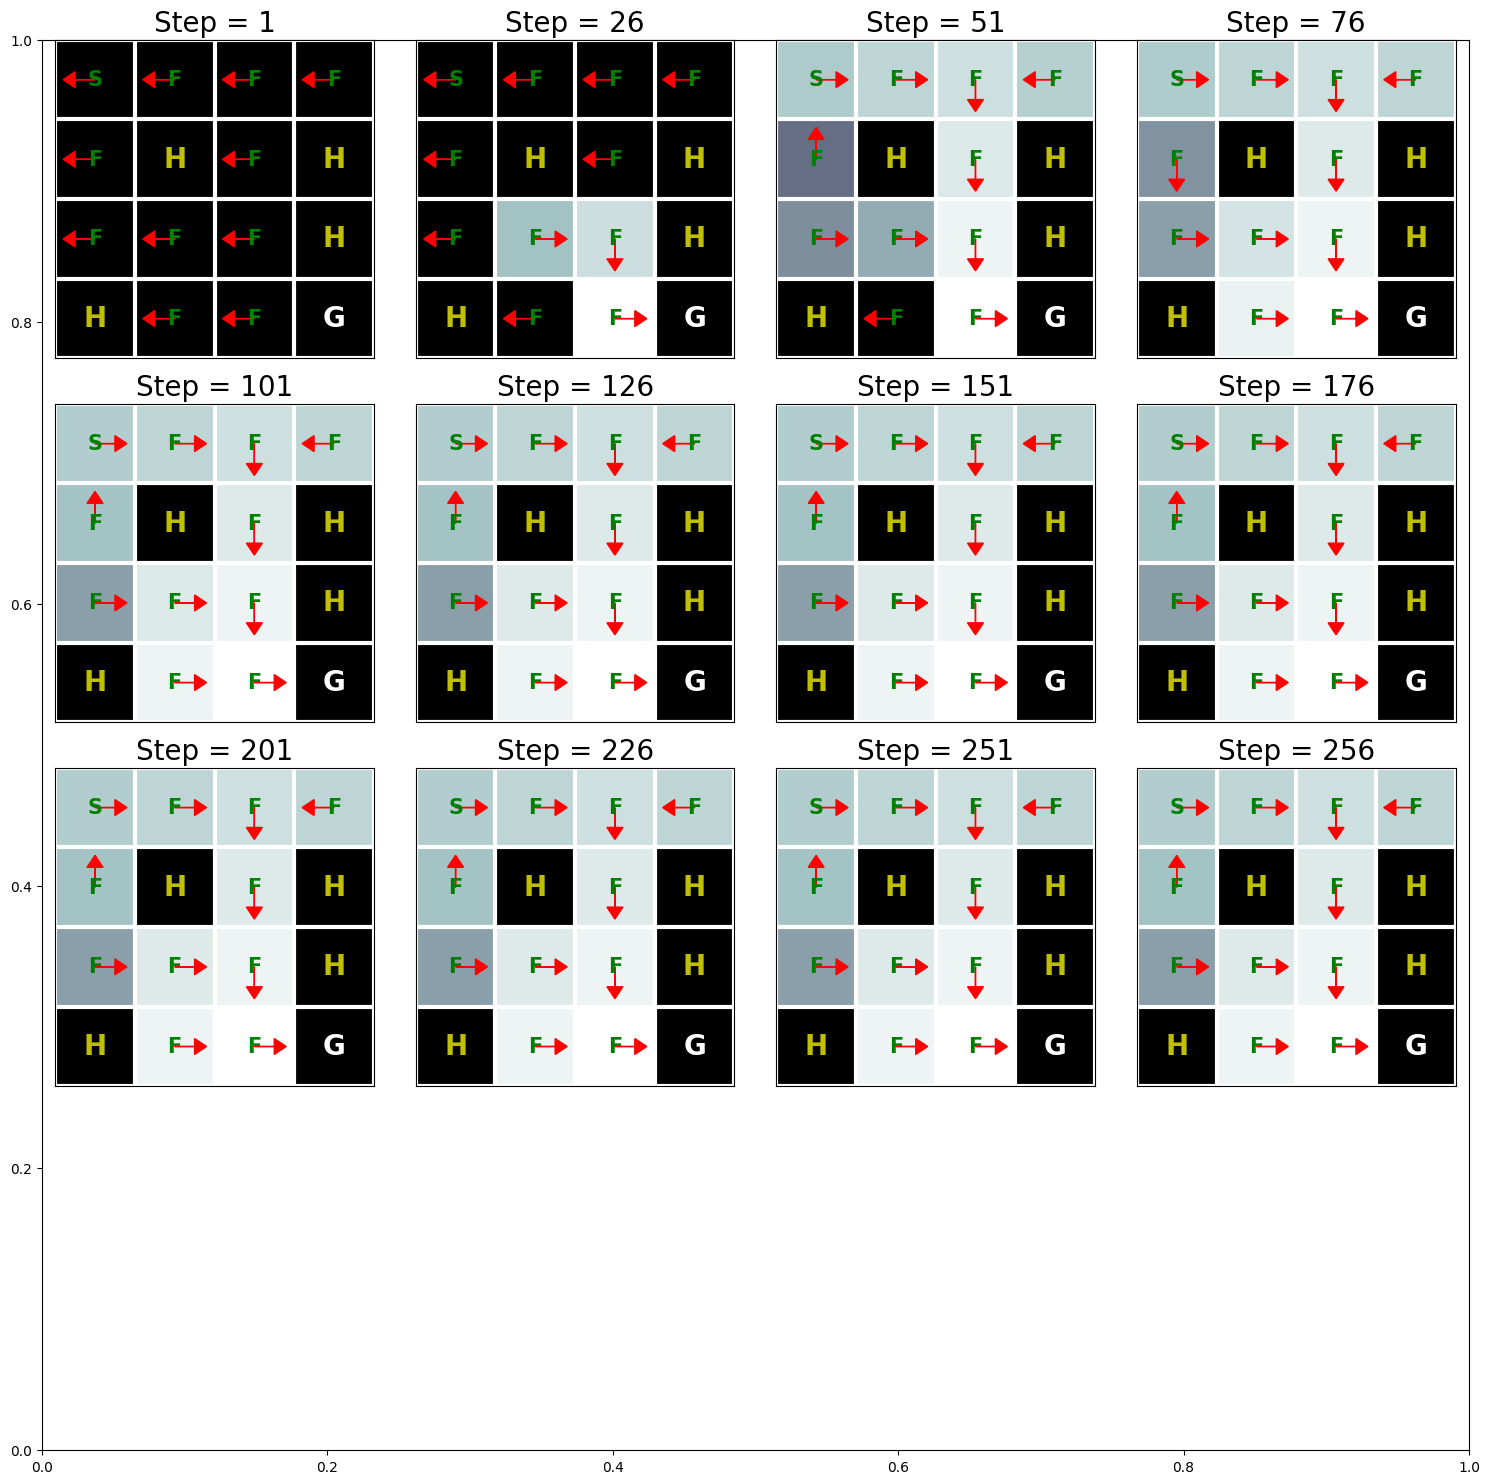

In [3]:

def q_learning(env_info, gamma, num_iters, alpha, epsilon_start, epsilon_end):
    env_desc = env_info['desc']  # 2D array specifying what each grid item means
    env = env_info['env']  # The Gymnasium environment object
    num_states = env_info['num_states']
    num_actions = env_info['num_actions']

    Q  = np.zeros((num_states, num_actions))
    V  = np.zeros((num_iters + 1, num_states))
    pi = np.zeros((num_iters + 1, num_states))
    episode_returns = []  # Per-episode return, for the learning curve

    for k in range(1, num_iters + 1):
        # Linearly anneal epsilon over episodes
        epsilon = epsilon_start + (epsilon_end - epsilon_start) * (
            (k - 1) / max(1, num_iters - 1))
        # Reset environment
        state, _ = env.reset()
        done = False
        episode_return = 0.0
        while not done:
            # Select an action for a given state and acts in env based on selected action
            action = e_greedy(env, Q, state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_return += reward

            # Q-update: mask the bootstrap term only at *terminal* states
            # (their value is zero). A truncated episode is merely cut off
            # by the time limit, so we still bootstrap from the next state.
            if terminated:
                y = reward
            else:
                y = reward + gamma * np.max(Q[next_state,:])
            Q[state, action] = Q[state, action] + alpha * (y - Q[state, action])

            # Move to the next state
            state = next_state
        episode_returns.append(episode_return)
        # Record max value and max action for visualization purpose only
        for s in range(num_states):
            V[k,s]  = np.max(Q[s,:])
            pi[k,s] = np.argmax(Q[s,:])
    d2l.show_Q_function_progress(env_desc, V[1:], pi[1:])
    return np.array(episode_returns)

episode_returns = q_learning(env_info=env_info, gamma=gamma,
                             num_iters=num_iters, alpha=alpha,
                             epsilon_start=epsilon_start,
                             epsilon_end=epsilon_end)

This result shows that Q-Learning finds an optimal policy for this problem, and it does not need the full run to do so: in this run the greedy path from the start state is in place after roughly fifty episodes, as the panels above show. One caveat is worth stating: its value estimates are accurate only for the state-action pairs the robot visits often, and entries it rarely tries remain near their initialization. When we compare with the Value Iteration algorithm's result (see that section), Value Iteration needs far fewer iterations, because it has access to the full MDP whereas Q-Learning does not.

The grid above shows the end product; the reward curve shows the learning as it happened. Each training episode on FrozenLake returns $1$ if the robot reached the goal and $0$ otherwise, so the raw signal is a jittery sequence of zeros and ones and we smooth it with a moving average:

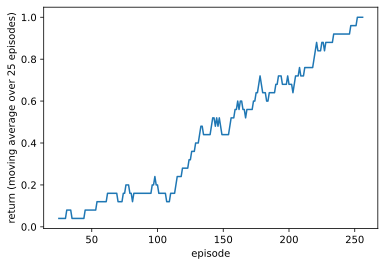

In [4]:

d2l.show_return_curve(episode_returns, window=25)

The curve stays low while the robot explores and the goal is still a rare accident, climbs once the first successes propagate value backward through the table, and approaches one as $\epsilon$ anneals and the robot exploits what it has learned. By the end it strings together a perfect window of successes even though $\epsilon = 0.05$ keeps injecting the occasional random action: on this small grid, a single random step is usually recoverable.


## Summary
Q-Learning is one of the most fundamental reinforcement-learning algorithms. It has been at the epicenter of the recent success of reinforcement learning, most notably in learning to play video games [@mnih2013playing]. Implementing Q-learning does not require that we know the Markov decision process (MDP), e.g., the transition and reward functions, completely.

## Exercises

1. Try increasing the grid size to $8 \times 8$. Compared with $4 \times 4$ grid, how many iterations does it take to find the optimal value function?
1. Run the Q-Learning algorithm again with $\gamma$ (i.e. "gamma" in the above code) when it equals to $0$, $0.5$, and $1$ and analyze its results.
1. Experiment with different values of `epsilon_start`, `epsilon_end`, and the epsilon decay rate (the schedule that anneals $\epsilon$ during training). For example, try `epsilon_start=epsilon_end=0` (pure greedy), `epsilon_start=epsilon_end=0.5`, `epsilon_start=epsilon_end=1` (pure random), and contrast each with a slow-decay schedule. Analyze how the exploration schedule affects convergence speed and the quality of the learned policy.

[Discussions](https://d2l.discourse.group/t/12103)